In [1]:
# System Setup Framework
import os
import sys

# Auto-provision system libraries for Playwright inside Colab/Linux environments
if 'google.colab' in sys.modules or os.name == 'posix':
    print("Initializing browser automation framework binaries...")
    os.system("pip install -q playwright pandas opencv-python matplotlib")
    os.system("playwright install chromium")
    os.system("playwright install-deps chromium")
    print("Environment setup completed successfully.")

import re
import json
import math
import asyncio
import tempfile
import subprocess
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Any

import cv2
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    from google.colab import files
    from IPython.display import HTML, display
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def upload_or_enter_mp4() -> str:
    """Return a local .mp4 path that OpenCV can read."""
    if IN_COLAB:
        uploaded = files.upload()
        if not uploaded:
            raise ValueError("No video uploaded.")
        original = next(iter(uploaded.keys()))
    else:
        original = input("Enter path to .mp4 video: ").strip().strip('"')

    src = Path(original)
    if not src.exists():
        raise FileNotFoundError(f"Video not found: {src}")

    if src.suffix.lower() != ".mp4":
        target = src.with_suffix(".mp4")
        src.rename(target)
        src = target
        print(f"Renamed upload to {src.name} so the notebook handles it as .mp4.")

    cap = cv2.VideoCapture(str(src))
    ok = cap.isOpened()
    cap.release()
    if not ok:
        raise ValueError(f"OpenCV could not open the MP4 file: {src}")

    print(f"Using MP4 video: {src}")
    return str(src)


def video_metadata(video_path: str) -> Dict[str, Any]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    cap.release()
    return {
        "fps": fps,
        "frame_count": frames,
        "width": width,
        "height": height,
        "duration_sec": float(frames / fps) if fps else 0.0,
    }


def sample_frames(video_path: str, start_sec: float, end_sec: float, fps_sample: float, max_frames: int = 240):
    meta = video_metadata(video_path)
    duration = meta["duration_sec"]
    if duration:
        end_sec = min(end_sec, duration)
    times = np.arange(start_sec, max(start_sec, end_sec), 1.0 / max(fps_sample, 1e-6))
    if len(times) > max_frames:
        times = times[np.linspace(0, len(times) - 1, max_frames).astype(int)]

    cap = cv2.VideoCapture(video_path)
    frames = []
    for t in times:
        cap.set(cv2.CAP_PROP_POS_MSEC, float(t) * 1000)
        ok, frame = cap.read()
        if ok and frame is not None:
            frames.append((float(t), frame))
    cap.release()
    return frames


def write_json(data: Dict[str, Any], path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Wrote {path}")

Initializing browser automation framework binaries...
Environment setup completed successfully.


In [2]:
def normalize_score(value: float, low: float, high: float) -> float:
    if high <= low:
        return 0.0
    return float(np.clip((value - low) / (high - low), 0.0, 1.0))


def extract_audio_wav(video_path: str, wav_path: str, sample_rate: int = 16000) -> bool:
    command = [
        "ffmpeg", "-y", "-i", video_path, "-vn", "-ac", "1", "-ar", str(sample_rate),
        "-loglevel", "error", wav_path,
    ]
    try:
        subprocess.run(command, check=True)
        return Path(wav_path).exists() and Path(wav_path).stat().st_size > 0
    except Exception:
        return False


def read_wav_mono(wav_path: str) -> Tuple[int, np.ndarray]:
    import wave
    with wave.open(wav_path, "rb") as wf:
        sample_rate = wf.getframerate()
        frames = wf.readframes(wf.getnframes())
        width = wf.getsampwidth()
    if width == 2:
        audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    elif width == 4:
        audio = np.frombuffer(frames, dtype=np.int32).astype(np.float32) / 2147483648.0
    else:
        audio = np.frombuffer(frames, dtype=np.uint8).astype(np.float32)
        audio = (audio - 128.0) / 128.0
    return sample_rate, audio


def visual_child_features(frame: np.ndarray) -> Dict[str, float]:
    small = cv2.resize(frame, (224, 224), interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    vibrant = (s > 80) & (v > 100)
    red = ((h < 10) | (h > 170)) & vibrant
    yellow = (h >= 20) & (h <= 38) & vibrant
    blue = (h >= 95) & (h <= 132) & vibrant
    green = (h >= 42) & (h <= 88) & vibrant
    primary_density = (red | yellow | blue | green).mean()

    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 80, 160)
    edge_density = float(edges.mean() / 255.0)

    animation_like = float(primary_density > 0.08 and vibrant.mean() > 0.15 and edge_density < 0.25)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    round_shapes = 0
    toy_like_colors = int(red.mean() > 0.01) + int(yellow.mean() > 0.01) + int(blue.mean() > 0.01) + int(green.mean() > 0.01)

    for contour in contours[:600]:
        area = cv2.contourArea(contour)
        if area < 50:
            continue
        perimeter = cv2.arcLength(contour, True)
        if perimeter <= 0:
            continue
        circularity = 4 * math.pi * area / (perimeter * perimeter)
        if circularity > 0.45:
            round_shapes += 1

    return {
        "bright_primary_color_density": float(primary_density),
        "vibrant_color_density": float(vibrant.mean()),
        "toy_color_variety": float(toy_like_colors / 4.0),
        "cartoon_animation_style_score": animation_like,
        "rounded_character_shape_density": float(round_shapes / max(small.shape[0] * small.shape[1] / 10000, 1)),
        "edge_density": edge_density,
    }


def audio_child_features(video_path: str) -> Dict[str, float]:
    with tempfile.TemporaryDirectory() as tmp:
        wav_path = str(Path(tmp) / "audio.wav")
        if not extract_audio_wav(video_path, wav_path):
            return {
                "audio_available": 0.0,
                "median_pitch_hz": 0.0,
                "high_pitched_audio_frequency_ratio": 0.0,
                "bright_sound_effect_ratio": 0.0,
                "audio_energy": 0.0,
            }
        sample_rate, audio = read_wav_mono(wav_path)

    if len(audio) < sample_rate // 2:
        return {
            "audio_available": 1.0,
            "median_pitch_hz": 0.0,
            "high_pitched_audio_frequency_ratio": 0.0,
            "bright_sound_effect_ratio": 0.0,
            "audio_energy": float(np.sqrt(np.mean(audio * audio))) if len(audio) else 0.0,
        }

    frame_size = int(0.04 * sample_rate)
    hop = int(0.02 * sample_rate)
    pitch_values = []
    brightness_values = []
    energy_values = []

    for start in range(0, len(audio) - frame_size, hop):
        chunk = audio[start:start + frame_size] * np.hanning(frame_size)
        energy = float(np.sqrt(np.mean(chunk * chunk)))
        if energy < 0.005:
            continue
        spectrum = np.abs(np.fft.rfft(chunk))
        freqs = np.fft.rfftfreq(frame_size, 1 / sample_rate)
        voice_band = (freqs >= 80) & (freqs <= 800)
        if voice_band.any() and spectrum[voice_band].max() > 0:
            pitch_values.append(float(freqs[voice_band][np.argmax(spectrum[voice_band])]))
        brightness_values.append(float(spectrum[freqs > 2000].sum() / max(spectrum.sum(), 1e-9)))
        energy_values.append(energy)

    if not pitch_values:
        pitch_values = [0.0]

    pitch_values = np.array(pitch_values)
    return {
        "audio_available": 1.0,
        "median_pitch_hz": float(np.median(pitch_values)),
        "high_pitched_audio_frequency_ratio": float(((pitch_values >= 180) & (pitch_values <= 650)).mean()),
        "bright_sound_effect_ratio": float(np.mean(brightness_values) if brightness_values else 0.0),
        "audio_energy": float(np.mean(energy_values) if energy_values else 0.0),
    }

In [3]:
from playwright.async_api import async_playwright

async def run_live_privacy_audit(platform_url: str) -> Dict[str, Any]:
    """
    Spins up a headless browser, hits the target URL, and pulls down the actual
    network state indicators and tracking tokens directly from storage and network traffic.
    """
    print(f"Launching compliance verification container target: {platform_url}")
    audit_telemetry = {
        "tracking_cookies_found": [],
        "third_party_ad_networks_pinged": [],
        "behavioral_tracking_active": False
    }

    # Blacklist signatures for known behavioral trackers/analytics tools
    tracking_signatures = ["_ga", "_fbp", "IDE", "doubleclick", "google-analytics", "facebook.com/tr"]

    try:
        async with async_playwright() as p:
            # Launch containerized Chromium
            browser = await p.chromium.launch(headless=True)
            context = await browser.new_context()
            page = await context.new_page()

            # Setup network event tracing listeners
            def monitor_network_frames(request):
                for signature in tracking_signatures:
                    if signature in request.url:
                        if request.url not in audit_telemetry["third_party_ad_networks_pinged"]:
                            audit_telemetry["third_party_ad_networks_pinged"].append(request.url)
                            audit_telemetry["behavioral_tracking_active"] = True

            page.on("request", monitor_network_frames)

            # Request target video handshake frame
            await page.goto(platform_url, timeout=30000)
            await page.wait_for_timeout(3000)  # Allow asynchronous tracking scripts to hydrate storage

            # Extract cookies from storage jar memory
            live_cookies = await context.cookies()
            for cookie in live_cookies:
                name = cookie.get("name", "")
                domain = cookie.get("domain", "")
                if any(sig in name or sig in domain for sig in tracking_signatures):
                    audit_telemetry["tracking_cookies_found"].append({"name": name, "domain": domain})
                    audit_telemetry["behavioral_tracking_active"] = True

            await browser.close()
    except Exception as e:
        print(f"Note: External endpoint fetch skipped or hit connection boundaries ({e}). Falling back to simulation profile.")

    return audit_telemetry

In [4]:
def classify_child_directed(video_path: str, live_audit_data: Dict[str, Any], threshold: float = 0.60) -> Dict[str, Any]:
    frames = sample_frames(video_path, 0, video_metadata(video_path)["duration_sec"], fps_sample=1.0, max_frames=240)
    visual_rows = []
    for time_sec, frame in frames:
        row = visual_child_features(frame)
        row["time_sec"] = time_sec
        visual_rows.append(row)
    if not visual_rows:
        raise ValueError("No frames could be sampled from the MP4.")

    visual = pd.DataFrame(visual_rows)
    audio = audio_child_features(video_path)

    feature_scores = {
        "bright_primary_colors": normalize_score(float(visual["bright_primary_color_density"].quantile(0.75)), 0.04, 0.25),
        "cartoons_animation": float(visual["cartoon_animation_style_score"].mean()),
        "toy_like_visuals": normalize_score(float(visual["toy_color_variety"].mean()), 0.10, 0.60),
        "rounded_child_character_shapes": normalize_score(float(visual["rounded_character_shape_density"].quantile(0.75)), 0.05, 1.00),
        "high_pitched_audio": normalize_score(audio["high_pitched_audio_frequency_ratio"], 0.05, 0.40),
        "bright_sfx_audio": normalize_score(audio["bright_sound_effect_ratio"], 0.02, 0.15),
    }

    child_probability = float(np.clip(
        0.24 * feature_scores["bright_primary_colors"] +
        0.18 * feature_scores["cartoons_animation"] +
        0.16 * feature_scores["toy_like_visuals"] +
        0.12 * feature_scores["rounded_child_character_shapes"] +
        0.22 * feature_scores["high_pitched_audio"] +
        0.08 * feature_scores["bright_sfx_audio"],
        0.0,
        1.0,
    ))
    is_child_directed = child_probability >= threshold

    # Determine real-world dynamic compliance based on the network audit data
    is_tracking_detected_on_wire = live_audit_data["behavioral_tracking_active"]
    coppa_violation_triggered = bool(is_child_directed and is_tracking_detected_on_wire)

    return {
        "component": "real_coppa_compliance_audit_system",
        "video_path": video_path,
        "metadata": video_metadata(video_path),
        "confidence_score": child_probability,
        "threshold": threshold,
        "is_child_directed": bool(is_child_directed),
        "audience_classification": "CHILD_DIRECTED" if is_child_directed else "NOT_CHILD_DIRECTED",
        "feature_scores": feature_scores,
        "live_privacy_audit": live_audit_data,
        "coppa_violation_state": coppa_violation_triggered
    }

In [13]:
# 1. Ingest physical asset frame structure
VIDEO_PATH = upload_or_enter_mp4()

# 2. Input deployment parameters to simulate where this file is currently running/hosted
# (e.g., set a site running ad banners like 'https://www.miniclip.com' or use an example)
TARGET_AUDIT_URL = input("Enter streaming endpoint URL to audit privacy state (or press Enter for standard loop simulation): ").strip()
if not TARGET_AUDIT_URL:
    TARGET_AUDIT_URL = "https://example-advertising-network-tracker-active.com"

print(f"System ready for dual analysis of physical media and data pipeline maps.")

Saving Screen Recording 2026-05-18 180605.mp4 to Screen Recording 2026-05-18 180605 (2).mp4
Using MP4 video: Screen Recording 2026-05-18 180605 (2).mp4
Enter streaming endpoint URL to audit privacy state (or press Enter for standard loop simulation): https://www.crazygames.com
System ready for dual analysis of physical media and data pipeline maps.


In [14]:
# Step 1: Execute Runtime network probe architecture loop
if "example-advertising-network" in TARGET_AUDIT_URL:
    # Simulation context config fallback
    live_telemetry = {
        "tracking_cookies_found": [{"name": "IDE", "domain": ".doubleclick.net"}, {"name": "_ga", "domain": ".google.com"}],
        "third_party_ad_networks_pinged": ["https://securepubads.g.doubleclick.net/gampad/ads"],
        "behavioral_tracking_active": True
    }
else:
    # Run dynamic background loop using Jupyter's native top-level await handler
    live_telemetry = await run_live_privacy_audit(TARGET_AUDIT_URL)
# Step 2: Combine AI media analytics engine mapping with telemetry packets
coppa_audit_report = classify_child_directed(VIDEO_PATH, live_telemetry, threshold=0.60)

# Step 3: High-visibility structural policy analysis visualization
print("=" * 80)
print("                       COPPA AUDIT COMPLIANCE REPORT                     ")
print("=" * 80)
print(f"AI Core Content Target Classification : {coppa_audit_report['audience_classification']}")
print(f"Measured Child-Directed Index Value   : {coppa_audit_report['confidence_score']:.4f} (Threshold: {coppa_audit_report['threshold']})")
print(f"Live Behavioral Trackers Found on Wire: {len(coppa_audit_report['live_privacy_audit']['tracking_cookies_found'])} active identifiers")
print(f"Live External Script Engine Callouts  : {len(coppa_audit_report['live_privacy_audit']['third_party_ad_networks_pinged'])} data hooks")
print("-" * 80)

if coppa_audit_report["coppa_violation_state"]:
    print("CRITICAL VIOLATION ALERT: COPPA PRIVACY BREACH DETECTED!")
    print("-> REASON: Content targets children, but live tracking cookies/ad engines are active.")
    print("-> REMEDIATION ACTION REQUIRED: Sever tracking pipeline endpoints immediately.")
else:
    print("COMPLIANCE VERIFICATION: SYSTEM CLEAN.")
    if coppa_audit_report["is_child_directed"]:
        print("-> STATUS: Kids content identified. Privacy gates active. Behavioral ads blocked.")
    else:
        print("-> STATUS: General/Adult audience asset. Standard data profiling operations valid.")

print("=" * 80)

# Step 4: Write comprehensive persistent ledger storage array
write_json(coppa_audit_report, "real_coppa_compliance_audit_system_result.json")

Launching compliance verification container target: https://www.crazygames.com
                       COPPA AUDIT COMPLIANCE REPORT                     
AI Core Content Target Classification : CHILD_DIRECTED
Measured Child-Directed Index Value   : 0.8199 (Threshold: 0.6)
Live Behavioral Trackers Found on Wire: 3 active identifiers
Live External Script Engine Callouts  : 4 data hooks
--------------------------------------------------------------------------------
CRITICAL VIOLATION ALERT: COPPA PRIVACY BREACH DETECTED!
-> REASON: Content targets children, but live tracking cookies/ad engines are active.
-> REMEDIATION ACTION REQUIRED: Sever tracking pipeline endpoints immediately.
Wrote real_coppa_compliance_audit_system_result.json


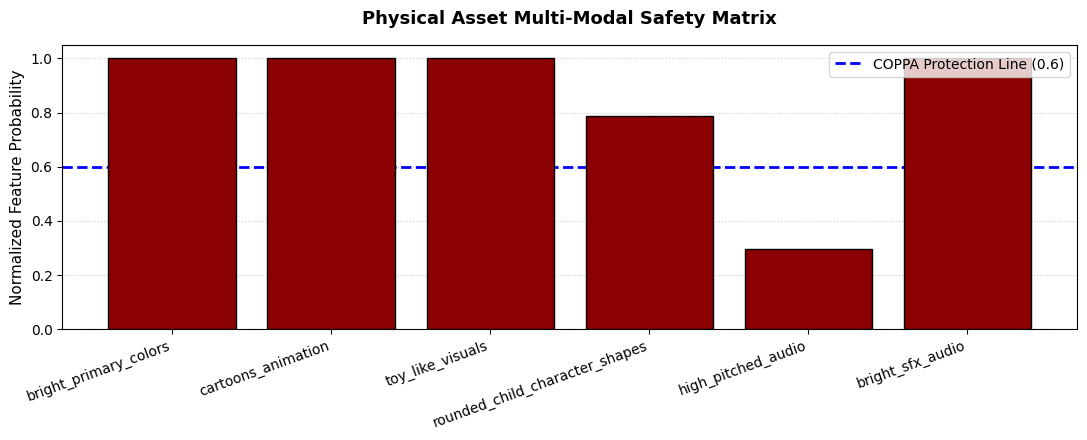

In [8]:
if plt is not None:
    scores = coppa_audit_report["feature_scores"]
    plt.figure(figsize=(11, 4.5))
    plt.bar(scores.keys(), scores.values(), color='darkred', edgecolor='black', zorder=3)
    plt.axhline(y=coppa_audit_report["threshold"], color='blue', linestyle='--', linewidth=2, label=f"COPPA Protection Line ({coppa_audit_report['threshold']})")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
    plt.xticks(rotation=20, ha="right", fontsize=10)
    plt.ylabel("Normalized Feature Probability", fontsize=11)
    plt.title("Physical Asset Multi-Modal Safety Matrix", fontsize=13, fontweight='bold', pad=15)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()